# 02 · Feature Engineering
**Universidad Alfonso X el Sabio — Bases de Datos e Inteligencia Artificial 2025-2026**

Este notebook transforma el dataset crudo en los artefactos que consumirán los notebooks de modelado.  
Las decisiones de selección de features se justifican con los hallazgos de `01_EDA.ipynb`.

**Salidas de este notebook** (guardadas en `outputs/processed/`):

| Fichero | Contenido |
|---|---|
| `X_train.npy`, `X_val.npy`, `X_test.npy` | Arrays preprocesados |
| `y_train.npy`, `y_val.npy`, `y_test.npy` | Targets correspondientes |
| `preprocessor.pkl` | ColumnTransformer ajustado (para inferencia futura) |
| `meta.json` | Nombres de features, class weights, pos_weight, shapes |

## 00 · Imports y configuracion

Cargamos las librerias necesarias e importamos las constantes y funciones del modulo `src/preprocessing.py`.
Fijar `SEED=42` garantiza que el split sea reproducible: cualquier persona que ejecute el notebook
obtendra exactamente los mismos conjuntos de train, val y test.

In [1]:
import sys, os, json, pickle
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from src.preprocessing import (
    TARGET, ALL_FEATURES, FEATURES_NUM, FEATURES_ORD, FEATURES_BIN,
    build_preprocessor,
)

SEED = 42
np.random.seed(SEED)

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR  = r'../Base de datos-20260512'
FIG_DIR   = r'../outputs/figures'
PROC_DIR  = r'../outputs/processed'
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

print('Entorno listo.')
# Nota: torch se importa en 03_models.ipynb, no aquí.
# pos_weight se guarda como float en meta.json para que 03 lo cargue.

Entorno listo.


## 01 · Carga y merge (5 ficheros - ECONOMICOS excluido)

Leemos los 5 ficheros CSV relevantes y los unimos por `paciente_id`.
El fichero **ECONOMICOS se descarta en este paso** porque sus variables (costes, ingresos, dias
de hospitalizacion) son *consecuencias* del diagnostico, no causas. Incluirlas provocaria
data leakage severo: el modelo aprenderia que *"paciente caro = cancer"*, lo cual es trivialmente
cierto pero inutil para predecir a pacientes sin diagnostico previo.

In [2]:
# ECONOMICOS se descarta desde la carga: el EDA demostró que coste_total,
# coste_farmaco, num_ingresos y dias_hospital son consecuencias del diagnóstico
# (diferencias de media >200 % entre clases) → data leakage severo.
bioquim   = pd.read_csv(f'{DATA_DIR}/CASOCANCER_01_BIOQUIMICOS.csv')
clinicos  = pd.read_csv(f'{DATA_DIR}/CASOCANCER_02_CLINICOS.csv')
geneticos = pd.read_csv(f'{DATA_DIR}/CASOCANCER_03_GENETICOS.csv')
generales = pd.read_csv(f'{DATA_DIR}/CASOCANCER_05_GENERALES.csv')
sociodemo = pd.read_csv(f'{DATA_DIR}/CASOCANCER_06_SOCIODEMOGRAFICOS.csv')

df = (
    bioquim
    .merge(clinicos,  on='paciente_id')
    .merge(geneticos, on='paciente_id')
    .merge(generales[['paciente_id', 'fumador', 'actividad_fisica']], on='paciente_id')
    .merge(sociodemo[['paciente_id', 'edad']], on='paciente_id')
)

print(f'Shape: {df.shape}  |  nulos: {df.isnull().sum().sum()}')
df.head(2)

Shape: (50001, 25)  |  nulos: 0


,paciente_id,glucosa,colesterol,trigliceridos,hemoglobina,leucocitos,plaquetas,creatinina,diabetes,hipertension,...,mut_BRCA1,mut_TP53,mut_EGFR,mut_KRAS,mut_PIK3CA,mut_ALK,mut_BRAF,fumador,actividad_fisica,edad
0,P1000000,94.66,205.32,130.31,16.62,10.08,252.46,0.84,0,0,...,0,0,0,0,0,0,0,0,Moderada,53
1,P1000001,103.94,235.17,149.65,13.09,7.21,171.32,0.81,0,0,...,0,0,0,0,0,0,0,0,Moderada,66


## 02 · Seleccion de features

A partir de los hallazgos del EDA (`01_EDA.ipynb`), cada variable recibe una decision explicita
de inclusion o exclusion con su justificacion cuantitativa.

Las 19 features seleccionadas se dividen en tres grupos segun la transformacion que recibiran:
- **8 numericas continuas** - se escalan con StandardScaler
- **1 ordinal** (`actividad_fisica`) - se codifica preservando el orden causal Baja < Moderada < Alta
- **10 binarias** (mutaciones, comorbilidades, fumador) - se dejan como estan (ya son 0/1)

Las listas definitivas viven en `src/preprocessing.py` para que todos los notebooks las importen
desde el mismo sitio y no haya definiciones duplicadas ni inconsistencias.

In [3]:
# Tabla de decisiones de selección
seleccion = [
    # (variable, decisión, evidencia del EDA)
    ('glucosa',           '✅ INCLUIR', 'Diferencia de media +7.3 mg/dL; peso +1.2 en modelo generativo'),
    ('hemoglobina',       '✅ INCLUIR', 'Correlación negativa con cáncer; peso +0.9 en generativo'),
    ('leucocitos',        '✅ INCLUIR', 'Proxy de inflamación crónica; peso +0.7 en generativo'),
    ('colesterol',        '✅ INCLUIR', 'Predictor bioquímico causal incluido en generativo'),
    ('trigliceridos',     '✅ INCLUIR', 'Asociado a obesidad; predictor bioquímico causal'),
    ('plaquetas',         '✅ INCLUIR', 'Predictor bioquímico causal'),
    ('creatinina',        '✅ INCLUIR', 'Predictor bioquímico causal'),
    ('edad',              '✅ INCLUIR', 'Único sociodemográfico en generativo; prevalencia cáncer crece con edad'),
    ('mut_BRCA1',         '✅ INCLUIR', 'Mayor lift genético: 5 % → 20 % en cancer=1 (+15 pp)'),
    ('mut_TP53',          '✅ INCLUIR', 'Lift +15 pp; peso +1.8 en generativo'),
    ('mut_KRAS',          '✅ INCLUIR', 'Lift +14 pp; peso +1.4 en generativo'),
    ('mut_EGFR',          '✅ INCLUIR', 'Lift +7.5 pp; peso +1.0 en generativo'),
    ('mut_PIK3CA',        '✅ INCLUIR', 'Lift +4.9 pp; peso +0.8 en generativo'),
    ('mut_BRAF',          '✅ INCLUIR', 'Lift +3.1 pp; peso +0.6 en generativo'),
    ('fumador',           '✅ INCLUIR', 'Lift +19 pp; mayor predictor binario; peso +1.5 en generativo'),
    ('actividad_fisica',  '✅ INCLUIR', 'Factor protector causal; pesos -1.2 / -0.6 en generativo'),
    ('obesidad',          '✅ INCLUIR', 'Lift +19 pp; peso +1.1 en generativo; riesgo causal, no leakage'),
    ('hipertension',      '✅ INCLUIR', 'Lift +10 pp; peso +0.5 en generativo'),
    ('diabetes',          '✅ INCLUIR', 'Lift +7 pp; comorbilidad correlacionada por diseño'),
    ('mut_ALK',           '❌ EXCLUIR', 'Lift ~0 pp (4.92 % vs 4.89 %); añade ruido sin señal'),
    ('enfermedad_cardiaca','❌ EXCLUIR', 'Lift +1 pp; ausente en modelo generativo'),
    ('asma',              '❌ EXCLUIR', 'Lift +0.2 pp; ausente en modelo generativo'),
    ('epoc',              '❌ EXCLUIR', 'Lift +1.8 pp; ausente en modelo generativo'),
    ('alcohol',           '❌ EXCLUIR', 'Constante (100 % = 1); varianza = 0'),
    ('vive',              '❌ EXCLUIR', 'Supervivencia al cierre: consecuencia del diagnóstico → leakage'),
    ('nivel_educativo / zona / estado_civil / ...', '❌ EXCLUIR', 'Sin señal en EDA; ausentes en generativo'),
]

df_sel = pd.DataFrame(seleccion, columns=['Variable', 'Decisión', 'Evidencia EDA'])
print(df_sel.to_string(index=False))
print(f'\nFeatures seleccionadas: {len(ALL_FEATURES)}')

                                   Variable  Decisión                                                           Evidencia EDA
                                    glucosa ✅ INCLUIR          Diferencia de media +7.3 mg/dL; peso +1.2 en modelo generativo
                                hemoglobina ✅ INCLUIR                Correlación negativa con cáncer; peso +0.9 en generativo
                                 leucocitos ✅ INCLUIR                   Proxy de inflamación crónica; peso +0.7 en generativo
                                 colesterol ✅ INCLUIR                      Predictor bioquímico causal incluido en generativo
                              trigliceridos ✅ INCLUIR                        Asociado a obesidad; predictor bioquímico causal
                                  plaquetas ✅ INCLUIR                                             Predictor bioquímico causal
                                 creatinina ✅ INCLUIR                                             Predictor bioquímico

In [4]:
# Construcción de X e y
X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

assert X.isnull().sum().sum() == 0, 'Nulos en X'
assert y.isnull().sum() == 0,       'Nulos en y'

print('Composición del feature set:')
print(f'  Numéricas continuas : {FEATURES_NUM}')
print(f'  Ordinal             : {FEATURES_ORD}  (Baja=0, Moderada=1, Alta=2)')
print(f'  Binarias            : {FEATURES_BIN}')
print(f'\n  Total              : {len(ALL_FEATURES)} features')
print(f'  Pacientes           : {len(X):,}')
print(f'  Positivos (cancer=1): {y.sum():,} ({y.mean():.2%})')

Composición del feature set:
  Numéricas continuas : ['glucosa', 'colesterol', 'trigliceridos', 'hemoglobina', 'leucocitos', 'plaquetas', 'creatinina', 'edad']
  Ordinal             : ['actividad_fisica']  (Baja=0, Moderada=1, Alta=2)
  Binarias            : ['fumador', 'diabetes', 'hipertension', 'obesidad', 'mut_BRCA1', 'mut_TP53', 'mut_EGFR', 'mut_KRAS', 'mut_PIK3CA', 'mut_BRAF']

  Total              : 19 features
  Pacientes           : 50,001
  Positivos (cancer=1): 9,644 (19.29%)


## 03 · Split estratificado train / val / test (70 / 15 / 15)

Dividimos el dataset en tres conjuntos. La **estratificacion** garantiza que la prevalencia
del ~19 % de positivos se conserva en los tres splits, evitando que el azar concentre
casos de cancer en un solo conjunto.

Cada conjunto tiene un rol estricto que **no debe violarse**:

| Split | Tamaño | Uso |
|---|---|---|
| **Train** | 70 % (~35 000) | Unico conjunto sobre el que se ajustan los modelos |
| **Val** | 15 % (~7 500) | Early stopping del MLP; optimizacion del umbral de clasificacion |
| **Test** | 15 % (~7 500) | Evaluacion final - se usa **una sola vez** al final de `03_models.ipynb` |

Evaluar con el test antes de tiempo y ajustar en funcion de ese resultado introduce
sesgo optimista en las metricas finales (data leakage temporal).

In [5]:
# La estratificación garantiza que los tres conjuntos mantienen la misma
# prevalencia del ~19 %, evitando que el azar concentre positivos en un split.
# Protocolo de uso de cada conjunto:
#   train → ajuste de todos los modelos
#   val   → early stopping (MLP), optimización de umbral de clasificación
#   test  → evaluación final, se usa UNA SOLA VEZ al final del notebook 03

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=SEED, stratify=y_temp
)

print(f'{'Split':<8} {'Pacientes':>10}  {'Positivos':>10}  {'Prevalencia':>12}')
print('-' * 46)
for name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'{name:<8} {len(ys):>10,}  {ys.sum():>10,}  {ys.mean():>12.2%}')

Split     Pacientes   Positivos   Prevalencia
----------------------------------------------
Train        34,999       6,750        19.29%
Val           7,501       1,447        19.29%
Test          7,501       1,447        19.29%


## 04 · Pesos de clase para el desbalance

Con un ratio de desbalance de **4.2:1** (80 % negativos, 19 % positivos), un modelo sin
correccion puede obtener ~80 % de accuracy prediciendo siempre "no cancer" — lo cual es
clinicamente inutil. Los pesos de clase le dicen al optimizador que un error en la clase
positiva (cancer no detectado) debe penalizarse mas que un error en la negativa.

Se calculan **dos formatos** porque sklearn y PyTorch los consumen de forma diferente:
- `class_weight` dict → para Logistic Regression y Random Forest (sklearn)
- `pos_weight` (ratio neg/pos) → para `BCEWithLogitsLoss` de PyTorch en el MLP

Ambos se calculan **solo con los datos de train** para no filtrar informacion de val/test.

In [6]:
# Los class weights se calculan SOLO en train.
# Dos formatos: sklearn (dict) y PyTorch (tensor pos_weight para BCEWithLogitsLoss).
# pos_weight = neg / pos: le dice a la loss que un error en clase positiva
# pesa 4.2 veces más que uno en clase negativa.
cw_vals = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: float(cw_vals[0]), 1: float(cw_vals[1])}

neg_train = int((y_train == 0).sum())
pos_train = int((y_train == 1).sum())
pos_weight_value = float(neg_train / pos_train)   # para BCEWithLogitsLoss

print(f'Train: {neg_train:,} negativos  |  {pos_train:,} positivos')
print(f'Ratio neg/pos : {pos_weight_value:.4f}')
print(f'class_weight  : {class_weight_dict}')
print(f'pos_weight    : {pos_weight_value:.4f}  (usado en BCEWithLogitsLoss de PyTorch)')

Train: 28,249 negativos  |  6,750 positivos
Ratio neg/pos : 4.1850
class_weight  : {0: 0.619473255690467, 1: 2.5925185185185184}
pos_weight    : 4.1850  (usado en BCEWithLogitsLoss de PyTorch)


## 05 · Pipeline de preprocesado

Construimos el transformador que convierte las 19 features en un array numerico listo para
los modelos. Cada tipo de variable recibe el tratamiento adecuado a su naturaleza:

| Tipo | Transformacion | Motivo |
|---|---|---|
| Numericas (8) | `StandardScaler` | Escala media=0, std=1 — necesario para LR y MLP |
| Ordinal (1) | `OrdinalEncoder` [Baja, Moderada, Alta] | Preserva el orden causal del factor protector |
| Binarias (10) | `passthrough` | Ya son 0/1; escalarlas no anade informacion |

**Regla critica — fit solo en train:**  
El scaler aprende la media y desviacion tipica de las features *unicamente* en train.
Luego aplica esos mismos parametros a val y test con `.transform()`.  
Si ajustasemos el scaler viendo val o test, estariamos filtrando informacion de esos
conjuntos al modelo (data leakage del preprocesado).

In [7]:
preprocessor = build_preprocessor()

X_train_p = preprocessor.fit_transform(X_train)   # fit aquí
X_val_p   = preprocessor.transform(X_val)          # solo transform
X_test_p  = preprocessor.transform(X_test)         # solo transform

print(f'Shapes tras preprocesado:')
print(f'  X_train_p : {X_train_p.shape}')
print(f'  X_val_p   : {X_val_p.shape}')
print(f'  X_test_p  : {X_test_p.shape}')

Shapes tras preprocesado:
  X_train_p : (34999, 19)
  X_val_p   : (7501, 19)
  X_test_p  : (7501, 19)


## 06 · Verificacion del preprocesado

Antes de guardar los arrays, comprobamos que las transformaciones se aplicaron correctamente.
Estas verificaciones detectan errores silenciosos que podrian degradar el rendimiento
de los modelos sin producir ningun error visible en tiempo de ejecucion.

Se comprueban tres cosas:
1. **Numericas en train**: media ~ 0 y std ~ 1 (el scaler funciono)
2. **Ordinal**: `actividad_fisica` toma exactamente los valores {0, 1, 2}
3. **Binarias**: siguen siendo 0 y 1, el passthrough no las altero

Ademas se muestra un grafico de distribuciones escaladas para inspeccion visual.

In [8]:
# Verificación 1: numéricas en train deben tener media ≈ 0 y std ≈ 1
# En val/test la media no será exactamente 0 (se escaló con estadísticos de train)
n_num = len(FEATURES_NUM)
num_train = X_train_p[:, :n_num]
num_val   = X_val_p[:, :n_num]

check = pd.DataFrame({
    'Feature'     : FEATURES_NUM,
    'Train media' : num_train.mean(axis=0).round(4),
    'Train std'   : num_train.std(axis=0).round(4),
    'Val media'   : num_val.mean(axis=0).round(4),
    'Val std'     : num_val.std(axis=0).round(4),
})
print('Verificación StandardScaler:')
print(check.to_string(index=False))

assert all(abs(num_train.mean(axis=0)) < 1e-6), 'Media train no es 0'
assert all(abs(num_train.std(axis=0)  - 1) < 1e-4), 'Std train no es 1'
print('\n✅ StandardScaler correcto')

Verificación StandardScaler:
      Feature  Train media  Train std  Val media  Val std
      glucosa         -0.0        1.0     0.0071   0.9985
   colesterol          0.0        1.0     0.0004   1.0060
trigliceridos          0.0        1.0    -0.0025   1.0015
  hemoglobina         -0.0        1.0    -0.0104   0.9966
   leucocitos          0.0        1.0    -0.0027   0.9964
    plaquetas          0.0        1.0     0.0011   0.9962
   creatinina          0.0        1.0    -0.0151   1.0042
         edad          0.0        1.0    -0.0007   0.9903

✅ StandardScaler correcto


In [9]:
# Verificación 2: actividad_fisica codificada como 0, 1, 2
ord_col = X_train_p[:, n_num]   # columna ordinal
valores_unicos = np.unique(ord_col)
print(f'Valores únicos de actividad_fisica tras OrdinalEncoder: {valores_unicos}')
assert set(valores_unicos) == {0.0, 1.0, 2.0}, 'Codificación ordinal incorrecta'

# Verificación 3: binarias sin cambio (0 y 1)
bin_block = X_train_p[:, n_num + 1:]
assert bin_block.min() == 0 and bin_block.max() == 1, 'Binarias alteradas'
print('✅ OrdinalEncoder correcto')
print('✅ Binarias intactas')

Valores únicos de actividad_fisica tras OrdinalEncoder: [0. 1. 2.]
✅ OrdinalEncoder correcto
✅ Binarias intactas


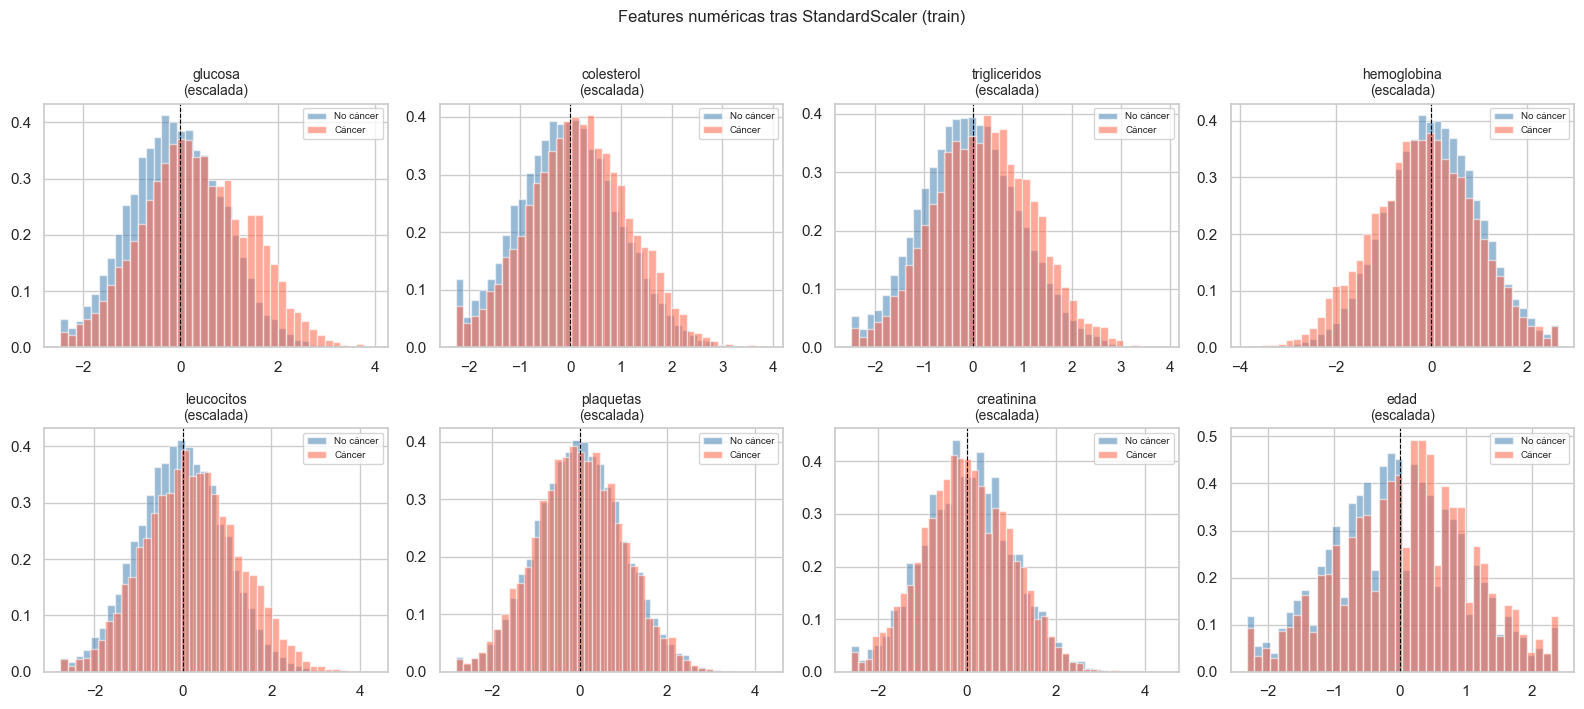

In [10]:
# Visualización: distribuciones tras escalado
# Las numéricas deben mostrar curvas centradas en 0; las binarias permanecen como pulsos 0/1
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for i, feat in enumerate(FEATURES_NUM):
    col_data = X_train_p[:, i]
    axes[i].hist(col_data[y_train == 0], bins=40, alpha=0.55,
                 color='steelblue', density=True, label='No cáncer')
    axes[i].hist(col_data[y_train == 1], bins=40, alpha=0.55,
                 color='tomato', density=True, label='Cáncer')
    axes[i].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].set_title(f'{feat}\n(escalada)', fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('Features numéricas tras StandardScaler (train)', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fe_01_numericas_escaladas.png', bbox_inches='tight')
plt.show()

In [11]:
# Prevalencia de features binarias en train (verificar que no hubo alteración)
bin_names = FEATURES_ORD + FEATURES_BIN
bin_block_all = X_train_p[:, n_num:]

prev_bin = pd.DataFrame({
    'Feature'       : bin_names,
    'Prevalencia (%)': (bin_block_all.mean(axis=0) * 100).round(1)
})
# La ordinal tiene media != prevalencia, la excluimos de la interpretación
print('Prevalencia features binarias en train (passthrough intacto):')
print(prev_bin[prev_bin['Feature'].isin(FEATURES_BIN)].to_string(index=False))

Prevalencia features binarias en train (passthrough intacto):
     Feature  Prevalencia (%)
     fumador             38.0
    diabetes             34.4
hipertension             44.2
    obesidad             35.4
   mut_BRCA1              8.0
    mut_TP53             12.0
    mut_EGFR              9.8
    mut_KRAS             13.1
  mut_PIK3CA              8.9
    mut_BRAF              6.9


## 07 · Guardado de artefactos

Persistimos todos los resultados del preprocesado en `outputs/processed/` para que
los notebooks de modelado puedan cargarlos directamente con `np.load()`, sin necesidad
de repetir la carga de CSVs ni el preprocesado.

Esto tiene dos ventajas importantes:
- **Reproducibilidad**: todos los modelos se entrenan con exactamente los mismos arrays
- **Eficiencia**: los notebooks de modelos arrancan en segundos en lugar de recalcular todo

El fichero `meta.json` guarda los metadatos clave (nombres de features, shapes, semilla,
class weights) para que el notebook de modelos no tenga que recalcular ni suponer nada.

In [12]:
# Guardamos los arrays procesados para que el notebook de modelos los cargue
# directamente, sin tener que repetir la carga, el merge y el preprocesado.
# También guardamos el preprocessor ajustado para inferencia futura.

# Arrays numpy
np.save(f'{PROC_DIR}/X_train.npy', X_train_p)
np.save(f'{PROC_DIR}/X_val.npy',   X_val_p)
np.save(f'{PROC_DIR}/X_test.npy',  X_test_p)
np.save(f'{PROC_DIR}/y_train.npy', y_train.values)
np.save(f'{PROC_DIR}/y_val.npy',   y_val.values)
np.save(f'{PROC_DIR}/y_test.npy',  y_test.values)

# Preprocessor ajustado
with open(f'{PROC_DIR}/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# Metadatos: todo lo que los notebooks posteriores necesitan saber
meta = {
    'features'         : ALL_FEATURES,
    'features_num'     : FEATURES_NUM,
    'features_ord'     : FEATURES_ORD,
    'features_bin'     : FEATURES_BIN,
    'target'           : TARGET,
    'n_features'       : len(ALL_FEATURES),
    'class_weight'     : class_weight_dict,
    'pos_weight'       : pos_weight_value,
    'train_size'       : int(len(y_train)),
    'val_size'         : int(len(y_val)),
    'test_size'        : int(len(y_test)),
    'prevalence_train' : float(y_train.mean()),
    'prevalence_val'   : float(y_val.mean()),
    'prevalence_test'  : float(y_test.mean()),
    'seed'             : SEED,
}
with open(f'{PROC_DIR}/meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Artefactos guardados en outputs/processed/:')
for fname in sorted(os.listdir(PROC_DIR)):
    size = os.path.getsize(f'{PROC_DIR}/{fname}')
    print(f'  {fname:<25}  {size/1024:>8.1f} KB')

Artefactos guardados en outputs/processed/:
  X_test.npy                   1113.6 KB
  X_train.npy                  5195.3 KB
  X_val.npy                    1113.6 KB
  meta.json                       1.1 KB
  preprocessor.pkl                2.6 KB
  y_test.npy                     58.7 KB
  y_train.npy                   273.6 KB
  y_val.npy                      58.7 KB


## 08 · Resumen

Vista consolidada de lo producido en este notebook.  
A partir de aqui, `03_models.ipynb` carga los artefactos y entrena los modelos.

In [13]:
print('=' * 60)
print('RESUMEN — FEATURE ENGINEERING')
print('=' * 60)
print(f'Features seleccionadas : {len(ALL_FEATURES)}')
print(f'  Numéricas (scaled)   : {len(FEATURES_NUM)}')
print(f'  Ordinal (encoded)    : {len(FEATURES_ORD)}')
print(f'  Binarias (passthrough): {len(FEATURES_BIN)}')
print()
print(f'Split  /  Pacientes  /  Prevalencia')
print(f'  Train    {len(y_train):>7,}        {y_train.mean():.2%}')
print(f'  Val      {len(y_val):>7,}        {y_val.mean():.2%}')
print(f'  Test     {len(y_test):>7,}        {y_test.mean():.2%}')
print()
print(f'pos_weight (PyTorch)   : {pos_weight_value:.4f}')
print(f'class_weight (sklearn) : {class_weight_dict}')
print()
print('Continúa en → 03_models.ipynb')

RESUMEN — FEATURE ENGINEERING
Features seleccionadas : 19
  Numéricas (scaled)   : 8
  Ordinal (encoded)    : 1
  Binarias (passthrough): 10

Split  /  Pacientes  /  Prevalencia
  Train     34,999        19.29%
  Val        7,501        19.29%
  Test       7,501        19.29%

pos_weight (PyTorch)   : 4.1850
class_weight (sklearn) : {0: 0.619473255690467, 1: 2.5925185185185184}

Continúa en → 03_models.ipynb
